In [4]:
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt

# Connect to the Northwind database
conn = sqlite3.connect('../data/northwind.db')

# Pull the monthly sales trend query
query = """
SELECT
    strftime('%Y-%m', o.OrderDate) AS OrderMonth,
    ROUND(SUM(od.UnitPrice * od.Quantity * (1 - od.Discount)), 2) AS MonthlyRevenue,
    COUNT(DISTINCT o.OrderID) AS NumberOfOrders
FROM Orders o
JOIN "Order Details" od
    ON o.OrderID = od.OrderID
GROUP BY OrderMonth
ORDER BY OrderMonth;
"""

df = pd.read_sql_query(query, conn)
df.head()

,OrderMonth,MonthlyRevenue,NumberOfOrders
0,2012-07,2066219.40,69
1,2012-08,3556875.79,122
2,2012-09,3440144.98,119
3,2012-10,3201529.96,111
4,2012-11,2980494.74,105


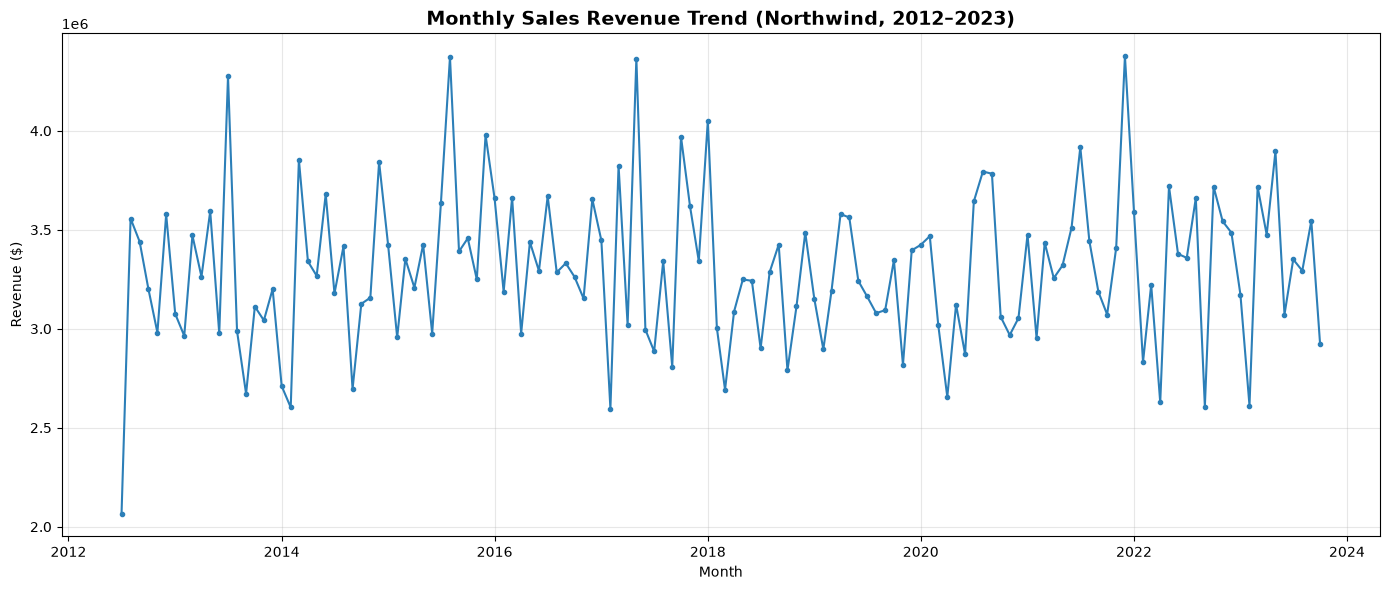

In [5]:
# Convert OrderMonth to datetime for proper time-series plotting
df['OrderMonth'] = pd.to_datetime(df['OrderMonth'])

plt.figure(figsize=(14, 6))
plt.plot(df['OrderMonth'], df['MonthlyRevenue'], marker='o', markersize=3, linewidth=1.5, color='#2c7fb8')
plt.title('Monthly Sales Revenue Trend (Northwind, 2012–2023)', fontsize=14, fontweight='bold')
plt.xlabel('Month')
plt.ylabel('Revenue ($)')
plt.grid(True, alpha=0.3)
plt.tight_layout()

# Save for the README
plt.savefig('../images/monthly_sales_trend.png', dpi=150)
plt.show()

In [6]:
df['Month'] = df['OrderMonth'].dt.month
seasonal_avg = df.groupby('Month')['MonthlyRevenue'].mean().round(2)
print(seasonal_avg)

Month
1     3379663.90
2     2915607.92
3     3403557.91
4     3135027.21
5     3541671.99
6     3203244.61
7     3337130.85
8     3459660.20
9     3164660.29
10    3253166.96
11    3186405.40
12    3581295.02
Name: MonthlyRevenue, dtype: float64


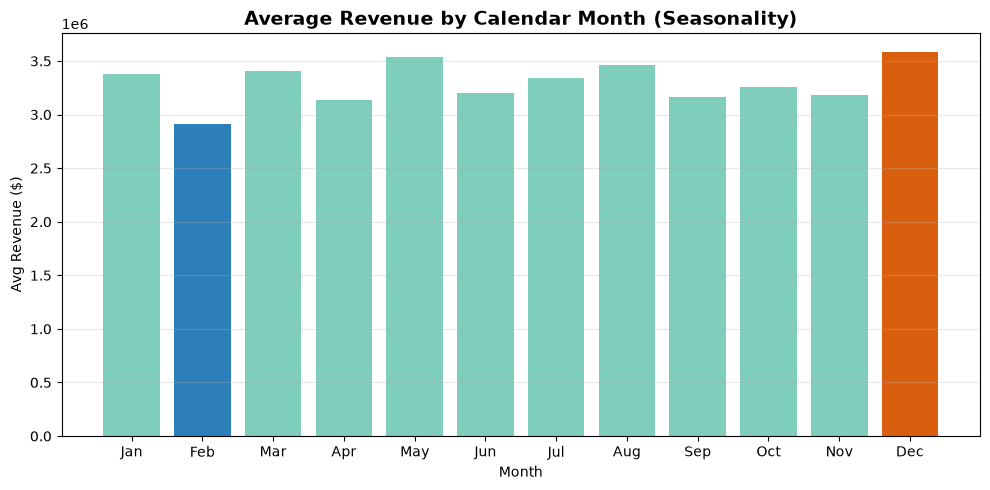

In [7]:
import calendar

plt.figure(figsize=(10, 5))
month_names = [calendar.month_abbr[m] for m in seasonal_avg.index]
colors = ['#d95f0e' if v == seasonal_avg.max() else '#2c7fb8' if v == seasonal_avg.min() else '#7fcdbb' for v in seasonal_avg.values]

plt.bar(month_names, seasonal_avg.values, color=colors)
plt.title('Average Revenue by Calendar Month (Seasonality)', fontsize=14, fontweight='bold')
plt.xlabel('Month')
plt.ylabel('Avg Revenue ($)')
plt.grid(True, axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('../images/seasonality_by_month.png', dpi=150)
plt.show()